In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h5py
import math
import os
import re

from matplotlib.patches import Patch
import matplotlib as mpl

In [24]:
filename = r'Y:\Members\Mia-Sanjana-Hadent\Processed Data\042425_2lc\week8-10-12-14-18\session_1_out.mat'
Cluster_detail_results = pd.read_csv( os.path.join(r'Y:\Members\Mia-Sanjana-Hadent\Processed Data\042425_2lc\week8-10-12-14-18\Cluster_detail_results.csv') )

In [25]:
# Read in values from clustersIdx, set automatically to the cluster value it represents rather than the actual value of the cell
if os.path.exists(filename):
    with h5py.File(filename, 'r') as file:
        library = file['Library']
        clustersIdx = library['clustersIdx']
        
        group_labels = []
        for i in range(clustersIdx.shape[0]):
            idxref = clustersIdx[i, 0]
            cluster_indices = np.array(file[idxref]).flatten()
            group_labels.extend([i+1] * len(cluster_indices))
        
        group_labels_df = pd.DataFrame(group_labels, columns=['GroupLabel'])
        print(f"Group labels shape: {group_labels_df.shape}")
else:
    raise FileNotFoundError('Could not find session_1_out.mat in dedicated subdirectory')


# Read in the feature values from clusters and stack on top of each other
if os.path.exists(filename):
    print('Loading session file from expected Results/test1 directory')
    with h5py.File(filename, 'r') as file:
        if 'Library' not in file:
            raise KeyError("The key 'Library' was not found in the session file.")
        library = file['Library']
        clusters = library['clusters']
        
        features_data = []
        
        for i in range(clusters.shape[0]):
            cref = clusters[i, 0]
            feature_data = np.array(file[cref]).T 
            features_data.append(feature_data)
        
        features_matrix = np.vstack(features_data)
        features_df = pd.DataFrame(features_matrix)
        print(f"Loaded {len(features_data)} clusters with total points: {features_matrix.shape[0]}")
        print(f"Combined matrix shape: {features_matrix.shape}")
else:
    raise FileNotFoundError('Could not find session_1_out.mat in dedicated subdirectory')
features_df['cluster'] = group_labels_df['GroupLabel'].values

Group labels shape: (120980, 1)
Loading session file from expected Results/test1 directory
Loaded 104 clusters with total points: 120980
Combined matrix shape: (120980, 30)


In [26]:
# Create combined matrix by matching first occurrence of each cluster in features_df to first occurrence in Cluster_detail_results, keeping order of Cluster_detail_results
def match_features_to_details(features_df, detail_df):
    matched_rows = []
    cluster_counts = {}
    for idx, detail_row in detail_df.iterrows():
        # print("combining")
        cluster_val = detail_row['ClusterIdx']
        count = cluster_counts.get(cluster_val, 0)
        feature_rows = features_df[features_df['cluster'] == cluster_val]
        if count < len(feature_rows):
            feature_row = feature_rows.iloc[count]
            combined_row = feature_row.to_dict()
            combined_row['Timestamp'] = detail_row['Timestamp'] if 'Timestamp' in detail_row else None
            combined_row['ClusterIdx'] = cluster_val
            combined_row['Folder_Name'] = detail_row['Folder_Name'] if 'Folder_Name' in detail_row else None
            matched_rows.append(combined_row)
            cluster_counts[cluster_val] = count + 1
        else:
            combined_row = {col: None for col in features_df.columns}
            combined_row['Timestamp'] = detail_row['Timestamp'] if 'Timestamp' in detail_row else None
            combined_row['ClusterIdx'] = cluster_val
            combined_row['Folder_Name'] = detail_row['Folder_Name'] if 'Folder_Name' in detail_row else None
            matched_rows.append(combined_row)
    return pd.DataFrame(matched_rows)
combined_matrix = match_features_to_details(features_df, Cluster_detail_results)
# print(combined_matrix)

# Automatically detects Week_Number from Folder_Name based on pattern of 'weekXX'
def get_week_number(folder_name):
    if isinstance(folder_name, str):
        match = re.search(r'week(\d+)', folder_name)
        if match:
            return int(match.group(1))
        
        # testing for arenas
        folder_name_lower = folder_name.lower()
        
        if "restricted" in folder_name_lower:
            return 1
        elif "open" in folder_name_lower:
            return 2
        elif "arenal" in folder_name_lower:
            return 3
        elif "arenam" in folder_name_lower:
            return 4
        elif "arenah" in folder_name_lower:
            return 5
        
    return None

combined_matrix['Week_Number'] = combined_matrix['Folder_Name'].apply(get_week_number)
combined_matrix['Week_Number'] = combined_matrix['Week_Number'].ffill()
#combined_matrix = combined_matrix[combined_matrix['Week_Number'] != 0]

# Clean up the finalized combined df (Column Titles : "Feature 1" ... "Feature 30" , "Timestamp" , "Cluster", "Week_Number", "Group")
feature_cols = {i: f'Feature{i+1}' for i in range(30)}
combined_matrix = combined_matrix.rename(columns=feature_cols)
combined_matrix = combined_matrix.drop(columns=['cluster'])
combined_matrix = combined_matrix.drop(columns=['Folder_Name'])
combined_matrix = combined_matrix.rename(columns={'ClusterIdx': 'Cluster'})

print(combined_matrix.head())

   Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  Feature7  \
0       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
1       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
2       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
3       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
4       0.0       0.0       0.0       0.0       0.0       0.0       0.0   

   Feature8  Feature9  Feature10  ...  Feature24  Feature25  Feature26  \
0       0.0       0.0        1.0  ...   0.000000   0.500000   0.500000   
1       0.0       0.0        1.0  ...   0.000000   0.383333   0.616667   
2       0.0       0.0        1.0  ...   0.000000   0.516667   0.483333   
3       0.0       0.0        1.0  ...   0.000000   0.600000   0.400000   
4       0.0       0.0        1.0  ...   0.116667   0.566667   0.166667   

   Feature27  Feature28  Feature29  Feature30  Timestamp  Cluster  Week_Number  
0        0.0        0.0

In [27]:
weeks = combined_matrix['Week_Number'].unique()
stage_names = [f"Stage {i}" for i in range(1, len(weeks) + 1)]

all_df = combined_matrix
week_map = {wk: i+1 for i, wk in enumerate(sorted(all_df["Week_Number"].unique()))}

stage_dfs = {
    f"stage{int(week)}": group_df.sort_values(by="Cluster", ascending=True).copy()
    for week, group_df in all_df.groupby("Week_Number", sort=True)
}


In [28]:
def create_cluster_usage_pie_charts(combined_matrix, save=False, output_dir=None):
    df = combined_matrix.copy()
    df = df.dropna(subset=['Cluster', 'Week_Number'])
    clusters = sorted(df['Cluster'].unique())
    weeks_order = sorted(df['Week_Number'].unique())

    cmap_name = 'tab10'
    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=min(weeks_order), vmax=max(weeks_order))
    week_colors = [cmap(norm(w)) for w in weeks_order]
    week_labels = [f'Week {int(w)}' for w in weeks_order]

    n_clusters = len(clusters)
    if n_clusters == 0:
        raise ValueError("No clusters found in combined_matrix to plot.")

    ncols = min(8, max(3, int(math.ceil(math.sqrt(n_clusters)))))
    nrows = int(math.ceil(n_clusters / ncols))
    cell_size = 2.4  
    fig_w = ncols * cell_size
    fig_h = nrows * cell_size
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)
    axes_flat = axes.ravel()

    for ax in axes_flat:
        ax.set_aspect('equal') 

    for i, cluster in enumerate(clusters):
        ax = axes_flat[i]
        counts = df.loc[df['Cluster'] == cluster, 'Week_Number'].value_counts().reindex(weeks_order, fill_value=0)
        total = int(counts.sum())
        if total == 0:
            ax.axis('off')
            continue

        display_labels = [lbl if cnt > 0 else '' for lbl, cnt in zip(week_labels, counts)]

        wedges, texts, autotexts = ax.pie(
            counts,
            labels=display_labels,
            colors=week_colors,
            autopct=lambda p: f'{p:.1f}%' if p > 0 else '',
            startangle=90,
            textprops={'fontsize': 6},
        )

        for at in autotexts:
            at.set_fontsize(4)   
        ax.set_title(f'Cluster {int(cluster)}', fontsize=7)

    
    for j in range(n_clusters, len(axes_flat)):
        axes_flat[j].axis('off')

    
    legend_handles = [Patch(facecolor=col, edgecolor='k', label=lbl) for col, lbl in zip(week_colors, week_labels)]
    fig.legend(handles=legend_handles, loc='center right', bbox_to_anchor=(0.99, 0.5), fontsize=7, frameon=False)

    fig.suptitle('Cluster Usage Distribution by Week', fontsize=12)
    plt.tight_layout(rect=[0, 0, 0.92, 0.99])  
    

    if save and output_dir:
        chart_output_dir = os.path.join(output_dir, 'cluster_usage_by_week_pie_plots' )
        os.makedirs(chart_output_dir, exist_ok=True)

        png_path = os.path.join(chart_output_dir, 'all_clusters_pies_by_week.png')
        svg_path = os.path.join(chart_output_dir, 'all_clusters_pies_by_week.svg')

        fig.savefig(png_path, dpi=300, bbox_inches='tight')
        fig.savefig(svg_path, bbox_inches='tight', format='svg')
        print(f'Saved combined figure with {n_clusters} cluster pies to: {png_path} and {svg_path}')

    plt.show(fig)
    plt.close(fig)

Saved combined figure with 104 cluster pies to: Y:\Members\Mia-Sanjana-Hadent\Visualizations\Output_TEST_DELETE\graphs\cluster_usage_by_week_pie_plots\all_clusters_pies_by_week.png and Y:\Members\Mia-Sanjana-Hadent\Visualizations\Output_TEST_DELETE\graphs\cluster_usage_by_week_pie_plots\all_clusters_pies_by_week.svg


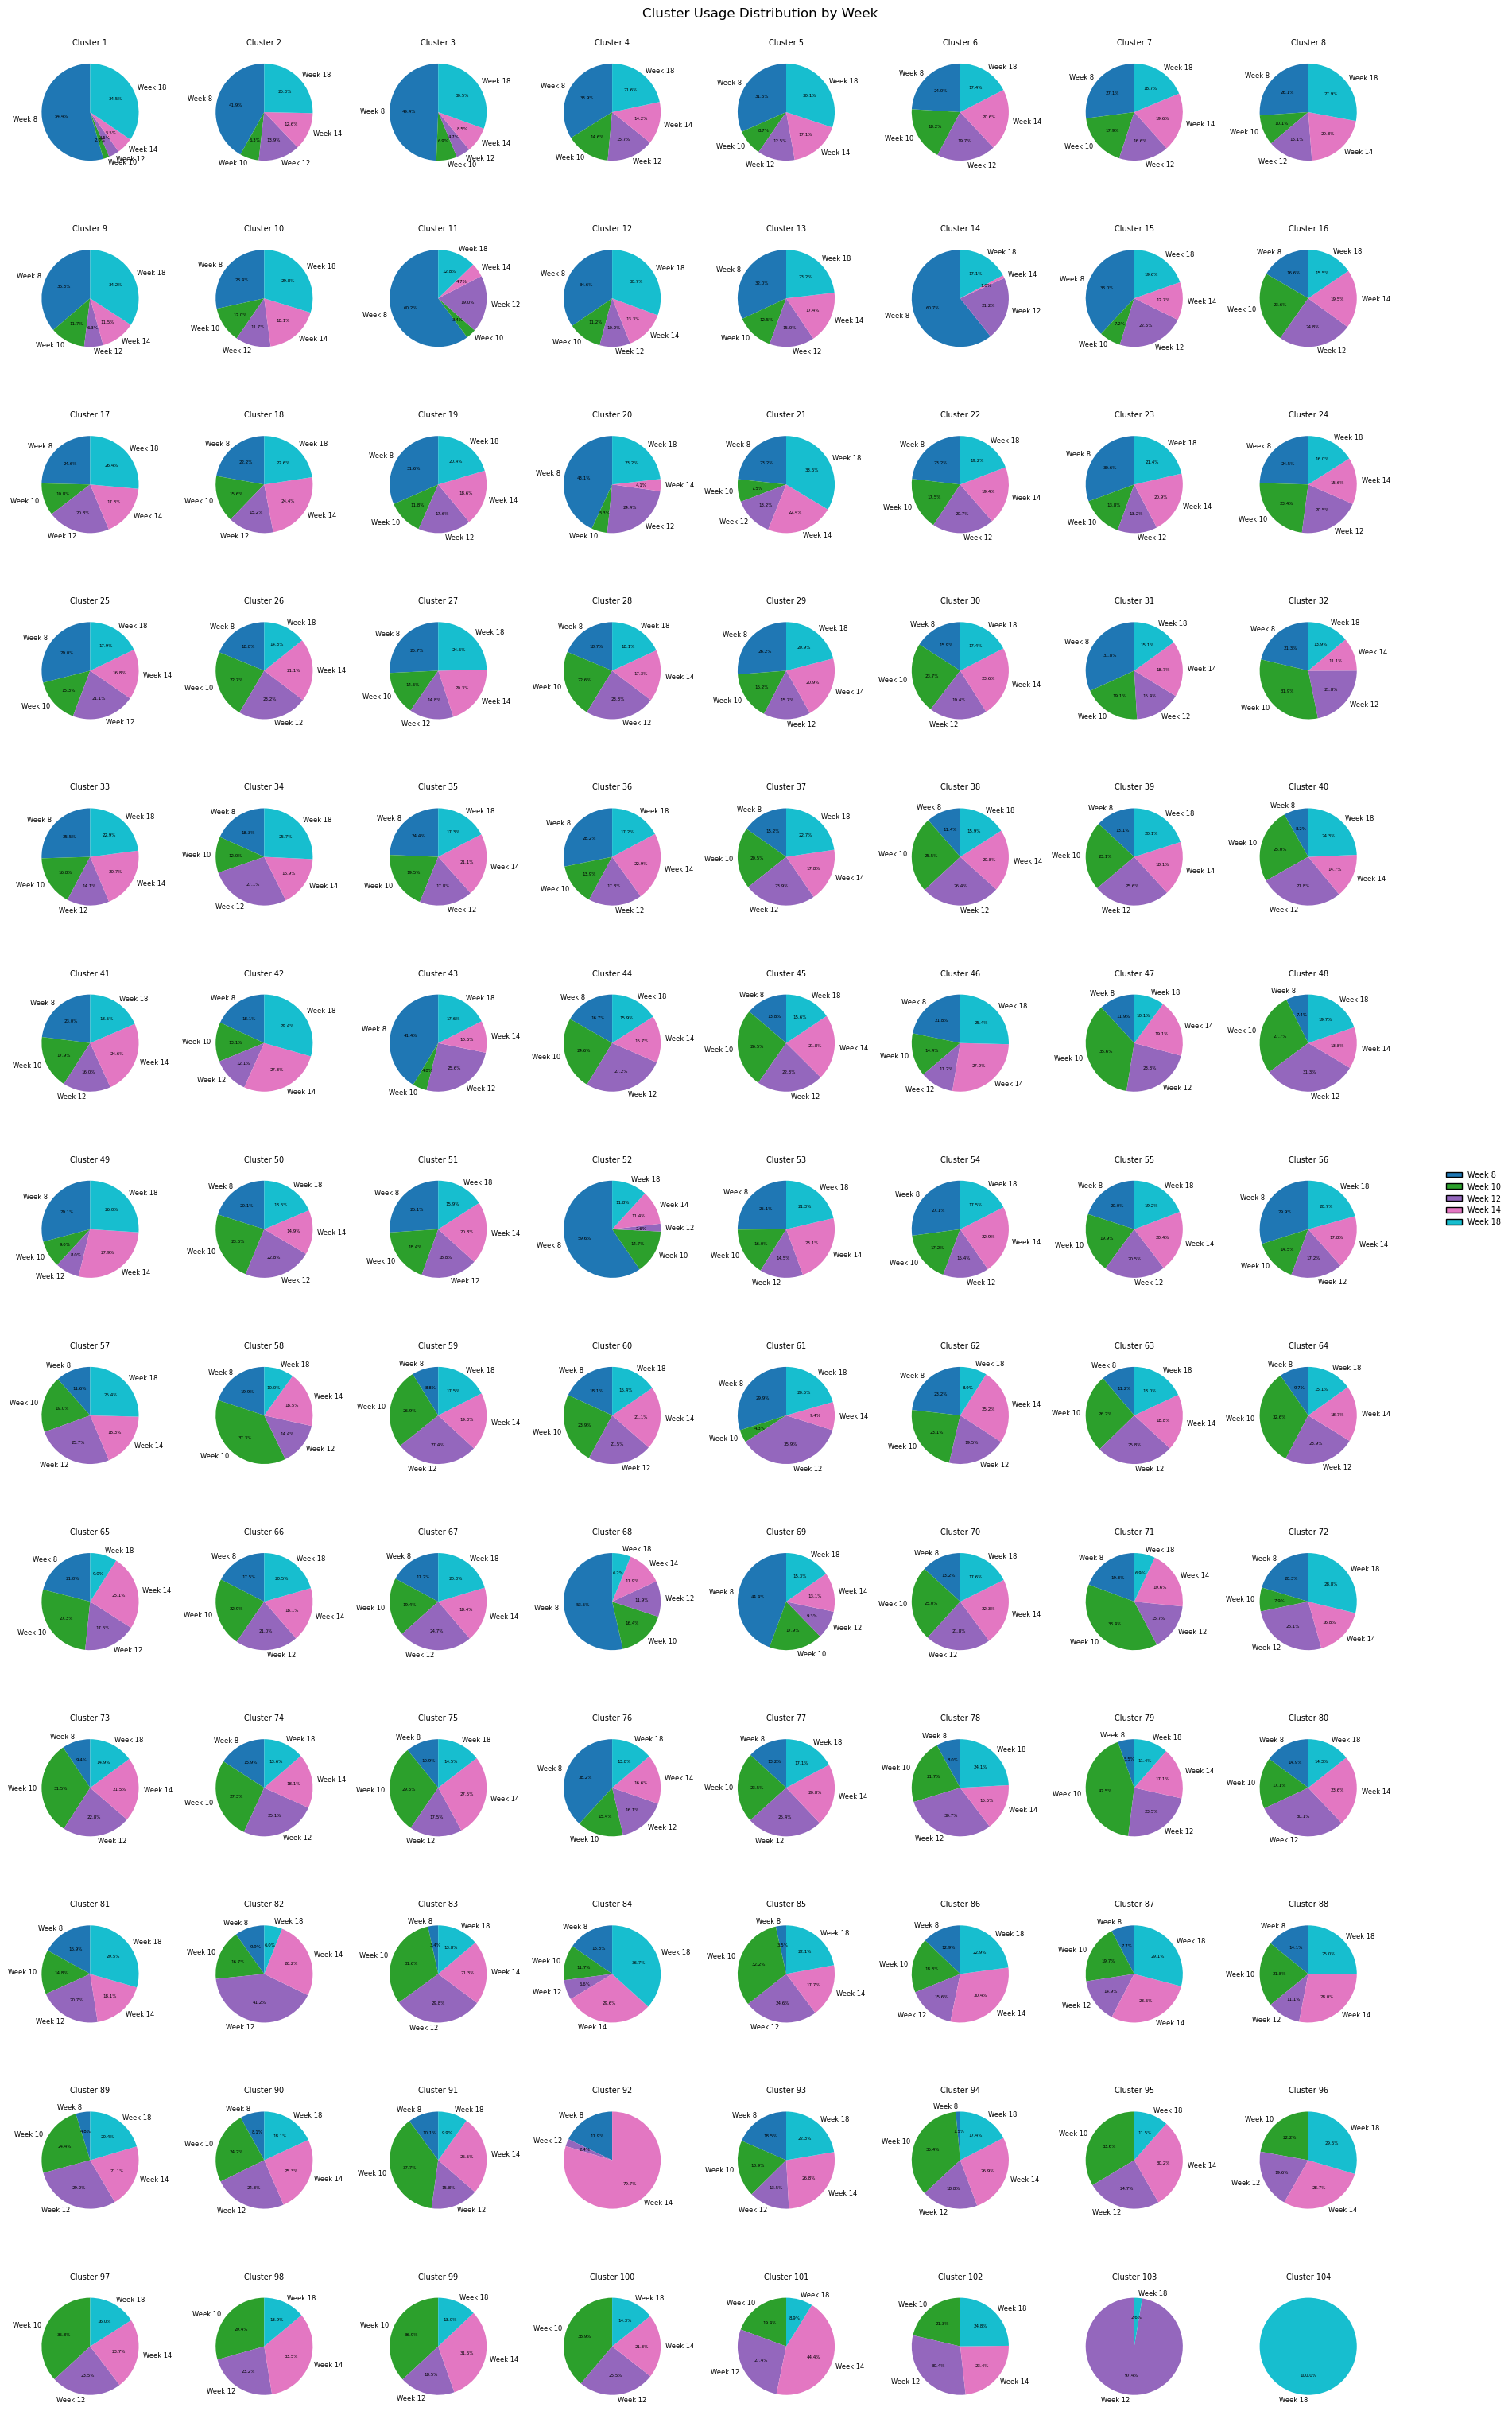

In [29]:
output_dir = r'Y:\Members\Mia-Sanjana-Hadent\Visualizations\Output_TEST_DELETE\graphs'
create_cluster_usage_pie_charts(combined_matrix, save=True, output_dir=output_dir)